In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV


In [18]:
from sklearn.datasets import load_iris
dat = load_iris()
df = pd.DataFrame(dat.data,columns=dat.feature_names)
df['target']=dat.target

In [19]:
df.sample(25)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
54,6.5,2.8,4.6,1.5,1
116,6.5,3.0,5.5,1.8,2
48,5.3,3.7,1.5,0.2,0
13,4.3,3.0,1.1,0.1,0
25,5.0,3.0,1.6,0.2,0
3,4.6,3.1,1.5,0.2,0
49,5.0,3.3,1.4,0.2,0
84,5.4,3.0,4.5,1.5,1
136,6.3,3.4,5.6,2.4,2
36,5.5,3.5,1.3,0.2,0


In [20]:
df.shape

(150, 5)

In [21]:
df['target'].shape

(150,)

In [22]:
X=df.drop("target",axis=1)
y=df['target']

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [24]:
from sklearn.tree import DecisionTreeRegressor

rt = DecisionTreeRegressor(criterion='squared_error',max_depth=5)

rt.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [25]:
y_pred = rt.predict(X_test)

In [26]:
from sklearn.metrics import r2_score,accuracy_score
r2_score(y_test,y_pred)

0.845890410958904

In [27]:
accuracy_score(y_test,y_pred)

0.9

[Text(0.3333333333333333, 0.9166666666666666, 'x[3] <= 0.8\nsquared_error = 0.666\nsamples = 120\nvalue = 1.033'),
 Text(0.16666666666666666, 0.75, 'squared_error = 0.0\nsamples = 38\nvalue = 0.0'),
 Text(0.25, 0.8333333333333333, 'True  '),
 Text(0.5, 0.75, 'x[2] <= 4.75\nsquared_error = 0.25\nsamples = 82\nvalue = 1.512'),
 Text(0.41666666666666663, 0.8333333333333333, '  False'),
 Text(0.3333333333333333, 0.5833333333333334, 'squared_error = 0.0\nsamples = 36\nvalue = 1.0'),
 Text(0.6666666666666666, 0.5833333333333334, 'x[2] <= 5.05\nsquared_error = 0.079\nsamples = 46\nvalue = 1.913'),
 Text(0.5, 0.4166666666666667, 'x[0] <= 6.5\nsquared_error = 0.24\nsamples = 10\nvalue = 1.6'),
 Text(0.3333333333333333, 0.25, 'x[1] <= 3.1\nsquared_error = 0.122\nsamples = 7\nvalue = 1.857'),
 Text(0.16666666666666666, 0.08333333333333333, 'squared_error = 0.0\nsamples = 6\nvalue = 2.0'),
 Text(0.5, 0.08333333333333333, 'squared_error = 0.0\nsamples = 1\nvalue = 1.0'),
 Text(0.6666666666666666, 0

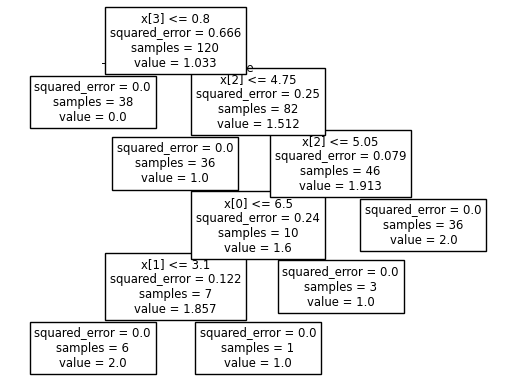

In [28]:
from sklearn.tree import plot_tree
plot_tree(rt)

## 
Above we can see the model is using gini impurity instead of entropy to calculate the impurity for selection of
column needed to be split with highest IG(informatin Gain)

NOTE: now making a prediction section where this model will predict based on input given by user
'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']



### for the input variable of all types 5.1,3.5,1.4,0.2 and it must give setosa

In [32]:
import numpy as np

def user_input():
    sepal_length = float(input("Enter sepal length in cm : "))
    sepal_width = float(input("Enter sepal width in cm : "))
    petal_length = float(input("Enter petal length in cm : "))
    petal_width = float(input("Enter petal width in cm : "))

    return np.array([[sepal_length, sepal_width, petal_length, petal_width]])

# get input
data = user_input()

# prediction
pred = rt.predict(data)

# extract value
pred = pred[0]

if pred == 0:
    print("The species of flower is setosa")
elif pred == 1:
    print("The species of flower is versicolor")
else:
    print("The species of flower is virginica")

The species of flower is setosa


d:\FeatureEngineering\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
